# LAB 3 - TIME SERIES

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Connect to Drive

In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

# file_path = "/content/drive/MyDrive/temperature.csv"
# df = pd.read_csv(file_path,  parse_dates=['datetime'])

# df = df.set_index('datetime')
# print('Dataset shape: {}'.format(df.shape))
# df.head()

Load dataset

In [2]:
df = pd.read_csv('temperature.csv', parse_dates=['datetime'])
df = df.set_index('datetime')
print('Dataset shape: {}'.format(df.shape))
df.head()

Dataset shape: (45253, 36)


,Vancouver,Portland,San Francisco,Seattle,Los Angeles,San Diego,Las Vegas,Phoenix,Albuquerque,Denver,...,Philadelphia,New York,Montreal,Boston,Beersheba,Tel Aviv District,Eilat,Haifa,Nahariyya,Jerusalem
datetime,,,,,,,,,,,,,,,,,,,,,
2012-10-01 12:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,309.100000,NaN,NaN,NaN
2012-10-01 13:00:00,284.630000,282.080000,289.480000,281.800000,291.870000,291.530000,293.410000,296.600000,285.120000,284.610000,...,285.630000,288.220000,285.830000,287.170000,307.590000,305.470000,310.580000,304.4,304.4,303.5
2012-10-01 14:00:00,284.629041,282.083252,289.474993,281.797217,291.868186,291.533501,293.403141,296.608509,285.154558,284.607306,...,285.663208,288.247676,285.834650,287.186092,307.590000,304.310000,310.495769,304.4,304.4,303.5
2012-10-01 15:00:00,284.626998,282.091866,289.460618,281.789833,291.862844,291.543355,293.392177,296.631487,285.233952,284.599918,...,285.756824,288.326940,285.847790,287.231672,307.391513,304.281841,310.411538,304.4,304.4,303.5
2012-10-01 16:00:00,284.624955,282.100481,289.446243,281.782449,291.857503,291.553209,293.381213,296.654466,285.313345,284.592530,...,285.850440,288.406203,285.860929,287.277251,307.145200,304.238015,310.327308,304.4,304.4,303.5


This dataset is consisted of 36 columns, corresponding to 36 different cities, and 45253 rows, giving the value of the temperature every hour from late 2012 to late 2017.

In [3]:
# Cith with the highest variation in yearly temperature

all_std = df.std(axis=0)
max_std = all_std.max()
city_max_std = df.columns[all_std==max_std][0]
print('City with highest temperature variation: {} ({} degrees)'.format(city_max_std,round(max_std,2)))

City with highest temperature variation: Minneapolis (12.77 degrees)


In [4]:
data = df[['San Francisco','Minneapolis']]
data.describe()

,San Francisco,Minneapolis
count,44460.000000,45240.000000
mean,288.155821,280.700489
std,5.332862,12.774979
min,272.300000,242.336667
25%,284.670000,271.790000
50%,287.610000,281.639000
75%,291.015167,291.310000
max,313.620000,308.240000


In [5]:
# Convert from Kelvin to Celcius

data = data-273.15
data.describe()

,San Francisco,Minneapolis
count,44460.000000,45240.000000
mean,15.005821,7.550489
std,5.332862,12.774979
min,-0.850000,-30.813333
25%,11.520000,-1.360000
50%,14.460000,8.489000
75%,17.865167,18.160000
max,40.470000,35.090000


# Visualization

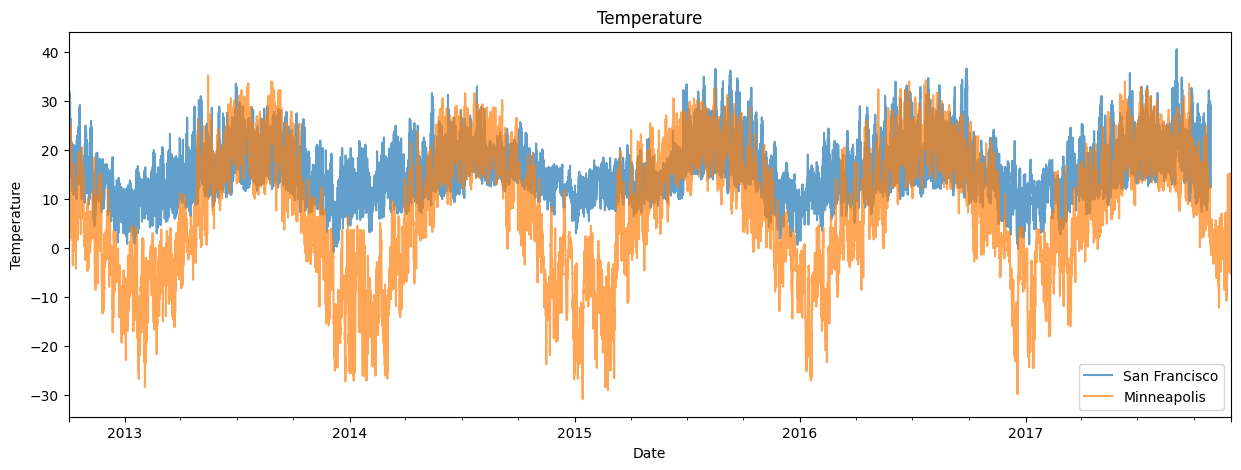

In [6]:
ax = data.plot(
    figsize=(15,5),
    subplots=False,
    title='Temperature',
    alpha=0.7
)

ax = plt.xlabel('Date')
ax = plt.ylabel('Temperature')

Cleaning the data

In [7]:
SF_non_missing = data['San Francisco'].dropna()
max_date = SF_non_missing.index.max()
data = data[data.index <= max_date]

In [8]:
# Check if there is still missing values

print(data.isna().sum())

San Francisco     1
Minneapolis      13
dtype: int64


Dealing missing values

In [ ]:
data_mean = data.resample('D').mean()
data_min = data.resample('D').min()
data_max = data.resample('D').max()
print('Resample shape: {}'.format(data_mean.shape))
data_mean.describe()

In [ ]:
print('Missing data now?')
print(data_mean.isna().sum())

Check the data after the resampling

In [ ]:
data = data_mean.plot(
    figsize=(15,5),
    subplots=False,
    title='Temperature',
    alpha=0.7
)

data = plt.fill_between(
    x=data_mean.index,
    y1=data_min['San Francisco'].values,
    y2=data_max['San Francisco'].values,
    alpha=0.3
)

data = plt.fill_between(
    x=data_mean.index,
    y1=data_min['Minneapolis'].values,
    y2=data_max['Minneapolis'].values,
    color='orange',
    alpha=0.3
)

data = plt.xlabel('Date')
data = plt.ylabel('Temperature')

The shadow around the curve shows the min-max values during that day, while the main line shows the mean value.

# Outliers

In [ ]:
data = plt.hist(data_mean['San Francisco'], alpha=0.5, label='San Francisco')
data = plt.hist(data_mean['Minneapolis'], alpha=0.5, label='Minneapolis')
data = plt.legend()

*   Values for San Francisco seem to follow a gaussian distribution with a small standard deviation, we can’t see any outliers in this data.

*   For Minneapolis the curve is less perfect, with a high skewness to the right side (negative skewness). We cannot say that any of this points are outliers though, since there is quite a few of them, also, in the visual representation of the temperatures we could see that really low values are reached every year.



# Looking for stationarity and autocorrelation

The Gaussian-shaped histagram we plotted earlier is a first clue the time series can be stationary.
Another clue is to compute some statistics on the time series in different time ranges and looking for a variation.

In [ ]:
cut = data_mean.index[int(0.5*len(data_mean))]
print('Mean before {}:'.format(cut))
print(data_mean.loc[:cut].mean())
print('')
print('Mean after {}:'.format(cut))
print(data_mean.loc[cut:].mean())
print('')
print('---------------------------')
print('')
print('Std before {}:'.format(cut))
print(data_mean.loc[:cut].std())
print('')
print('Std after {}:'.format(cut))
print(data_mean.loc[cut:].std())

We can see that the values are pretty close for San Francisco, but further away for Minneapolis, they are still close enough for the time series to be stationary since we need to take into account the standard deviation.

This method doesn’t prove or deny that our time series are stationary, it’s just indicates that it can be.

We can also use a statistical test to see if the non-stationarity hypothesis should be rejected Augmented Dickey-Fuller test.

In [ ]:
from statsmodels.tsa.stattools import adfuller
result = adfuller(data_mean['San Francisco'])
print('San Francisco')
print('--------------------------')
print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])
print('Critical Values:')
for key, value in result[4].items():
    print('\t%s: %.3f' % (key, value))
print('\n\n')

result = adfuller(data_mean['Minneapolis'])
print('Minneapolis')
print('--------------------------')
print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])
print('Critical Values:')
for key, value in result[4].items():
    print('\t%s: %.3f' % (key, value))

So, what do any of these values mean?

* The ADF Statistic is the Augmented Dicken-Fuller score, the more negative this value is, the higher the certainty that we can reject out null hypothesis (the probability that the time series is stationary).   
*   p-value is the level of confidance for the null hypothesis. A usual threshold for this value is 0.05, meaning that if p_value <= 0.05 we can reject the null hypothesis.
*   The rest of the values are the critical values for a 99%, 95% and 90% confidence intervals respectively.


So, what all this means in this case is that we can reject the null hypothesis for San Francisco since p is lower than 0.05, and also, the ADF score is lower than the limit for a 99% confidence interval. However, we fail to reject this hypothesis for Minneapolis, we could say it is stationarity with a confidence interval of 90%, but since the threshold was 95% (p = 0.05), we cannot reject it. This means we should difference the data before applying any model.



Some references to understand this tests:

[Stationary Data Tests for Time Series Forecasting](https://pythondata.com/stationary-data-tests-for-time-series-forecasting/)

[How to Check if Time Series Data is Stationary with Python](https://machinelearningmastery.com/time-series-data-stationary-python/)

# Autocorrelation

The last step is to check if the data is autocorrelated, which is necessary for using autoregression methods in future forecasts. Autocorrelation means a value depends on previous ones.

In [ ]:
import statsmodels.api as sm

print('San Francisco')
autocorr_SF = sm.graphics.tsa.plot_acf(data_mean['San Francisco'])
plt.show()

print('Minneapolis')
autocorr_M = sm.graphics.tsa.plot_acf(data_mean['Minneapolis'])
plt.show()

Let’s focus on the most important lags (the ones closer to the point), for example, data from one-year range.

In [ ]:
print('San Francisco')
autocorr_SF = sm.graphics.tsa.plot_acf(data_mean['San Francisco'], lags=365)
plt.show()

print('Minneapolis')
autocorr_M = sm.graphics.tsa.plot_acf(data_mean['Minneapolis'], lags=365)
plt.show()

More references:

*   [Statsmodels reference to acf function](https://www.statsmodels.org/dev/generated/statsmodels.tsa.stattools.acf.html)
*   [Statsmodels reference to pacf function](https://www.statsmodels.org/dev/generated/statsmodels.tsa.stattools.pacf.html)
*   [A Gentle Introduction to Autocorrelation and Partial Autocorrelation](https://machinelearningmastery.com/gentle-introduction-autocorrelation-partial-autocorrelation/)


# Trend — Seasonality decomposition

We can think about time series as a composition of trend, seasonality and residuals (noise or other random behaviour). The composition of the time series from this components can be bouth aditive or multiplicative:


*   Additive: *data = Trend + Seasonality + Residuals*
*   Multiplicative: *data = Trend · Seasonality · Residuals*

The Statsmodels package offers a function to extract this 3 component at once: [Seasonal_decompose](https://www.statsmodels.org/dev/generated/statsmodels.tsa.seasonal.seasonal_decompose.html)

The decomposition here is easy because we know the period to be 365 days.

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose as sd

sd_SF = sd(data_mean['San Francisco'], period = 365)
sd_M = sd(data_mean['Minneapolis'], period = 365)

fig = plt.figure(figsize=(15,10))

ax1 = plt.subplot(311)
fig1 = ax1.plot(sd_SF.trend, label='San Francisco', alpha=0.7)
fig1 = ax1.plot(sd_M.trend, label='Minneapolis', alpha=0.7)
fig1 = plt.legend()

ax2 = plt.subplot(312)
fig2 = ax2.plot(sd_SF.seasonal, label='San Francisco', alpha=0.7)
fig2 = ax2.plot(sd_M.seasonal, label='Minneapolis', alpha=0.7)
fig2 = plt.legend()

ax3 = plt.subplot(313)
fig3 = ax3.plot(sd_SF.resid, label='San Francisco', alpha=0.7)
fig3 = ax3.plot(sd_M.resid, label='Minneapolis', alpha=0.7)
fig3 = plt.legend()

Looking at this we can understand why we found the Minneapolis data to be non-stationary, there has been a clear increase in the temperature.

We can also find the trend by doing the moving average.